# YZ50 — Week 6: Building a WaveNet

- **Modular neural network layers** organize the components of a model into reusable classes such as **Linear, BatchNorm1d, Tanh, Embedding, Flatten, and Sequential**, revealing the fundamental structure behind `torch.nn`.

- In this week, the **MLP language model** from the previous weeks is first refactored into these custom layer classes, allowing the entire model to be represented as a single **Sequential architecture** independent of the training loop.

- The **context window** is then increased from **3 to 8 characters**, allowing the model to use a longer sequence of previous characters when predicting the next one.

- Instead of flattening all 8 characters at once, a **WaveNet-style hierarchical architecture** progressively combines neighboring character representations in pairs, reducing the sequence as **8 → 4 → 2 → 1** while allowing information to interact across increasingly larger contexts.

- Working with this hierarchical representation introduces **three-dimensional tensors** of the form **(batch, time, channels)**, making careful tensor shape tracking essential throughout the network.

- **BatchNorm1d** must therefore be adapted for three-dimensional inputs so that its statistics are computed across both the **batch and time dimensions**, while preserving the channel dimension.

In this week, I build the core neural network layers **from scratch**, extend the language model to a larger context window, construct a **WaveNet-style hierarchical architecture**, and explore how **tensor shapes, normalization, model capacity, and context structure** affect language-model performance.

# 1. Hafta 4'te yazdığın MLP + BatchNorm kodunu sınıflara topla: Linear, BatchNorm1d, Tanh, Embedding, Flatten, Sequential. Model tek bir Sequential olsun, eğitim döngüsü içindeki katmanların adını bilmesin. Loss eğrisi çizimini videodaki gibi düzelt.

In [115]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [116]:
# read in all the words
words = open('../data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [117]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [118]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [119]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [120]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [121]:
# Linear layer with optional bias, it does the matrix multiplication and adds the bias if it exists. It also has a parameters() method that returns a list of the parameters (weight and bias) so that we can easily get all the parameters of a model.
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight # matrix multiply
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# BatchNorm1d layer, it normalizes the input to have zero mean and unit variance, and then scales and shifts it using learnable parameters gamma and beta. It also maintains running estimates of the mean and variance for use during evaluation.
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim) # running mean
    self.running_var = torch.ones(dim) # running variance
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# Tanh activation function, it applies the hyperbolic tangent function element-wise to the input. It has no learnable parameters, so its parameters() method returns an empty list.
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# Embedding layer, it maps integer indices to dense vectors (embeddings). It has a weight matrix that is learned during training, and its parameters() method returns the weight matrix.
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# Flatten layer, it reshapes the input tensor to have shape (batch_size, -1), effectively flattening all dimensions except the batch dimension. It has no learnable parameters, so its parameters() method returns an empty list.
class Flatten:

  def __call__(self, x):
    self.out = x.view(x.size(0), -1)
    return self.out

  def parameters(self):
    return []

# FlattenConsecutive layer, it reshapes the input tensor by flattening consecutive time steps into a single dimension. It takes an integer n as an argument, which specifies how many consecutive time steps to flatten. It has no learnable parameters, so its parameters() method returns an empty list.
class FlattenConsecutive:
  
  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  
  def parameters(self):
    return []

# Sequential container, it takes a list of layers and applies them in order. It has a parameters() method that returns the parameters of all the layers in the sequence.
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [122]:
torch.manual_seed(42); # seed rng for reproducibility

In [123]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [124]:
def train():
  # same optimization as last time
  max_steps = 200000
  batch_size = 32
  lossi = []

  for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
      p.grad = None
    loss.backward()
    
    # update: simple SGD
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
      p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

train()

      0/ 200000: 3.2966
  10000/ 200000: 2.2322
  20000/ 200000: 2.4111
  30000/ 200000: 2.1004
  40000/ 200000: 2.3157
  50000/ 200000: 2.2104
  60000/ 200000: 1.9653
  70000/ 200000: 1.9767
  80000/ 200000: 2.6738
  90000/ 200000: 2.0837
 100000/ 200000: 2.2730
 110000/ 200000: 1.7491
 120000/ 200000: 2.2891
 130000/ 200000: 2.3443
 140000/ 200000: 2.1731
 150000/ 200000: 1.8246
 160000/ 200000: 1.7614
 170000/ 200000: 2.2419
 180000/ 200000: 2.0803
 190000/ 200000: 2.1326


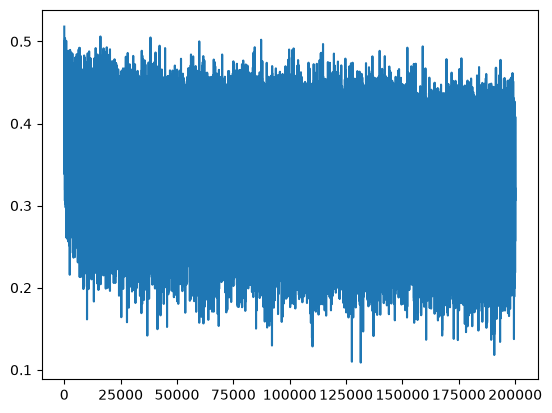

In [125]:
plt.plot(lossi)

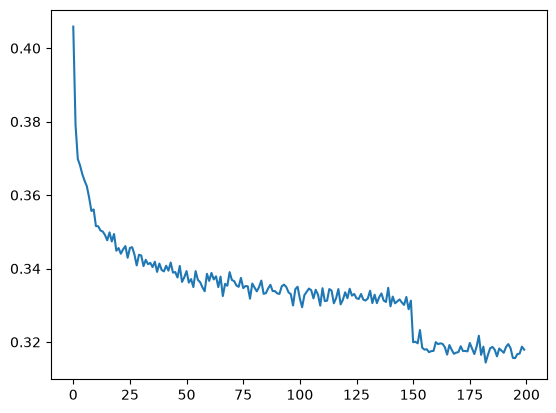

In [126]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [127]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [128]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0583252906799316
val 2.1065292358398438


In [129]:
def sample():
  # sample from the model
  for _ in range(20):
      
      out = []
      context = [0] * block_size # initialize with all ...
      while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
          break
      
      print(''.join(itos[i] for i in out)) # decode and print the generated word

sample()

ivon.
fanili.
thoommara.
kelo.
matyn.
leandr.
aleigh.
koldeniah.
prus.
carleen.
jah.
jorra.
alaya.
shonan.
vishylaharia.
juna.
vio.
orven.
mina.
laylee.


# 2. Bağlamı 3 harften 8'e çıkar. Başka hiçbir şeyi değiştirmeden aynı düz modeli koş, dev loss'u kaydet. Bu senin karşılaştırma tabanın. Parametre sayısı ne kadar arttı, loss ne kadar düştü, yaz.

In [130]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [137]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [131]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22097


In [132]:
train()

      0/ 200000: 3.3031
  10000/ 200000: 2.1251
  20000/ 200000: 1.7727
  30000/ 200000: 2.0378
  40000/ 200000: 2.3970
  50000/ 200000: 1.9122
  60000/ 200000: 2.2170
  70000/ 200000: 2.2689
  80000/ 200000: 1.9467
  90000/ 200000: 2.0907
 100000/ 200000: 2.0059
 110000/ 200000: 2.1550
 120000/ 200000: 2.5654
 130000/ 200000: 1.9536
 140000/ 200000: 1.9560
 150000/ 200000: 1.9639
 160000/ 200000: 1.7917
 170000/ 200000: 2.0384
 180000/ 200000: 1.8343
 190000/ 200000: 2.2642


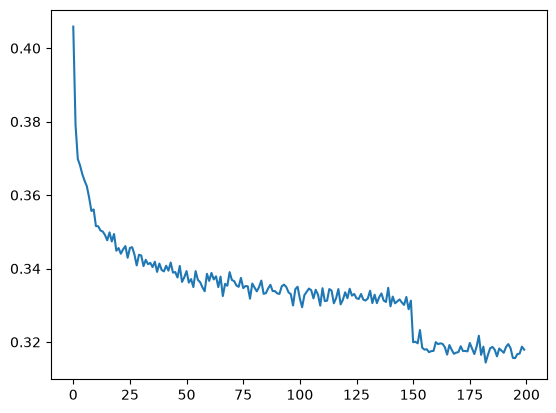

In [133]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [134]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [135]:
split_loss('train')
split_loss('val')

train 1.9209519624710083
val 2.028937578201294


In [136]:
sample()

braxlynn.
lashaun.
shrace.
jede.
rafir.
doujam.
limi.
selvorah.
yeshurey.
maaven.
catriana.
aryelith.
arpas.
nalorian.
shiton.
annavi.
ezria.
derreigh.
chilbegay.
karlene.


## Flat MLP Context-Length Comparison

| Configuration | Context length | Parameters | Dev loss |
|---|---:|---:|---:|
| Baseline flat MLP | 3 characters | 12,097 | 2.106529 |
| Flat MLP with longer context | 8 characters | 22,097 | 2.028938 |
| **Change** | **+5 characters** | **+10,000 (+82.66%)** | **-0.077592 (-3.68%)** |

Increasing the context from 3 to 8 characters added 10,000 parameters and reduced the dev loss by 0.077592.